<a href="https://colab.research.google.com/github/MariaRitaRR/C24-Inteligencia-Artificial/blob/main/Atividade_NP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importações

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [82]:
houses = pd.read_csv('kc_house_data.csv')
demographics = pd.read_csv('zipcode_demographics.csv')
future = pd.read_csv('future_unseen_examples.csv')

#Junção dos datasets
houses_full = houses.merge(demographics, on='zipcode', how='left')
future_full = future.merge(demographics, on='zipcode', how='left')

full_data = pd.concat([houses_full, future_full], ignore_index=True)


#Informações

In [83]:
full_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,7.129301e+09,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0.0,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0
1,6.414100e+09,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,0.0,0.0,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0
2,5.631500e+09,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0.0,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0
3,2.487201e+09,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,0.0,0.0,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0
4,1.954401e+09,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0.0,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5


In [84]:
print(full_data.info())
print(full_data.isnull().sum())
print(full_data.duplicated().sum())
display(full_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21713 entries, 0 to 21712
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      21613 non-null  float64
 1   date                    21613 non-null  object 
 2   price                   21613 non-null  float64
 3   bedrooms                21713 non-null  int64  
 4   bathrooms               21713 non-null  float64
 5   sqft_living             21713 non-null  int64  
 6   sqft_lot                21713 non-null  int64  
 7   floors                  21713 non-null  float64
 8   waterfront              21713 non-null  int64  
 9   view                    21713 non-null  int64  
 10  condition               21713 non-null  int64  
 11  grade                   21713 non-null  int64  
 12  sqft_above              21713 non-null  int64  
 13  sqft_basement           21713 non-null  int64  
 14  yr_built                21713 non-null

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
count,2.161300e+04,2.161300e+04,21713.000000,21713.000000,21713.000000,2.171300e+04,21713.000000,21713.000000,21713.000000,21713.000000,...,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000,21713.000000
mean,4.580302e+09,5.400881e+05,3.371068,2.114793,2079.589186,1.509966e+04,1.494658,0.007553,0.234007,3.409524,...,1.712154,0.049095,4.624004,1.835721,5.077649,14.396859,18.678441,5.131718,19.410169,8.835145
std,2.876566e+09,3.671272e+05,0.929668,0.769804,917.851282,4.136388e+04,0.540071,0.086582,0.766011,0.650680,...,10.873267,0.275476,13.239334,2.154380,2.473432,4.437207,2.786618,0.780286,7.046852,5.092877
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,11.000000,2.000000,6.000000,2.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,3.000000,11.000000,17.000000,5.000000,13.000000,4.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.615000e+03,1.500000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,5.000000,15.000000,19.000000,5.000000,19.000000,7.500000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068700e+04,2.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,0.000000,2.000000,7.000000,17.000000,20.000000,6.000000,25.000000,12.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,...,81.000000,2.000000,98.000000,11.000000,11.000000,25.000000,34.000000,7.000000,39.000000,24.000000


#Correlações

##Tabela completa de correlação

In [85]:
#Correlação das variáveis numéricas com o preço
corr = full_data.corr(numeric_only=True)
price_corr = corr['price'].sort_values(ascending=False)

price_corr

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
hous_val_amt,0.579733
medn_incm_per_prsn_amt,0.549911
bathrooms,0.525138
per_prfsnl,0.500262
per_bchlr,0.474896


##Tabela filtrada de correlação

In [86]:
# Filtrando correlações (usado no relatório)
price_corr_filtered = price_corr[
    abs(price_corr) >= 0.3
]
price_corr_filtered = price_corr_filtered.drop('price')

#Transforma a tabela em um df
price_corr_df = price_corr_filtered.reset_index()
price_corr_df.columns = ['Variável', 'Correlação']
price_corr_df

,Variável,Correlação
0,sqft_living,0.702035
1,grade,0.667434
2,sqft_above,0.605567
3,sqft_living15,0.585379
4,hous_val_amt,0.579733
5,medn_incm_per_prsn_amt,0.549911
6,bathrooms,0.525138
7,per_prfsnl,0.500262
8,per_bchlr,0.474896
9,view,0.397293


##Matriz de correlação completa

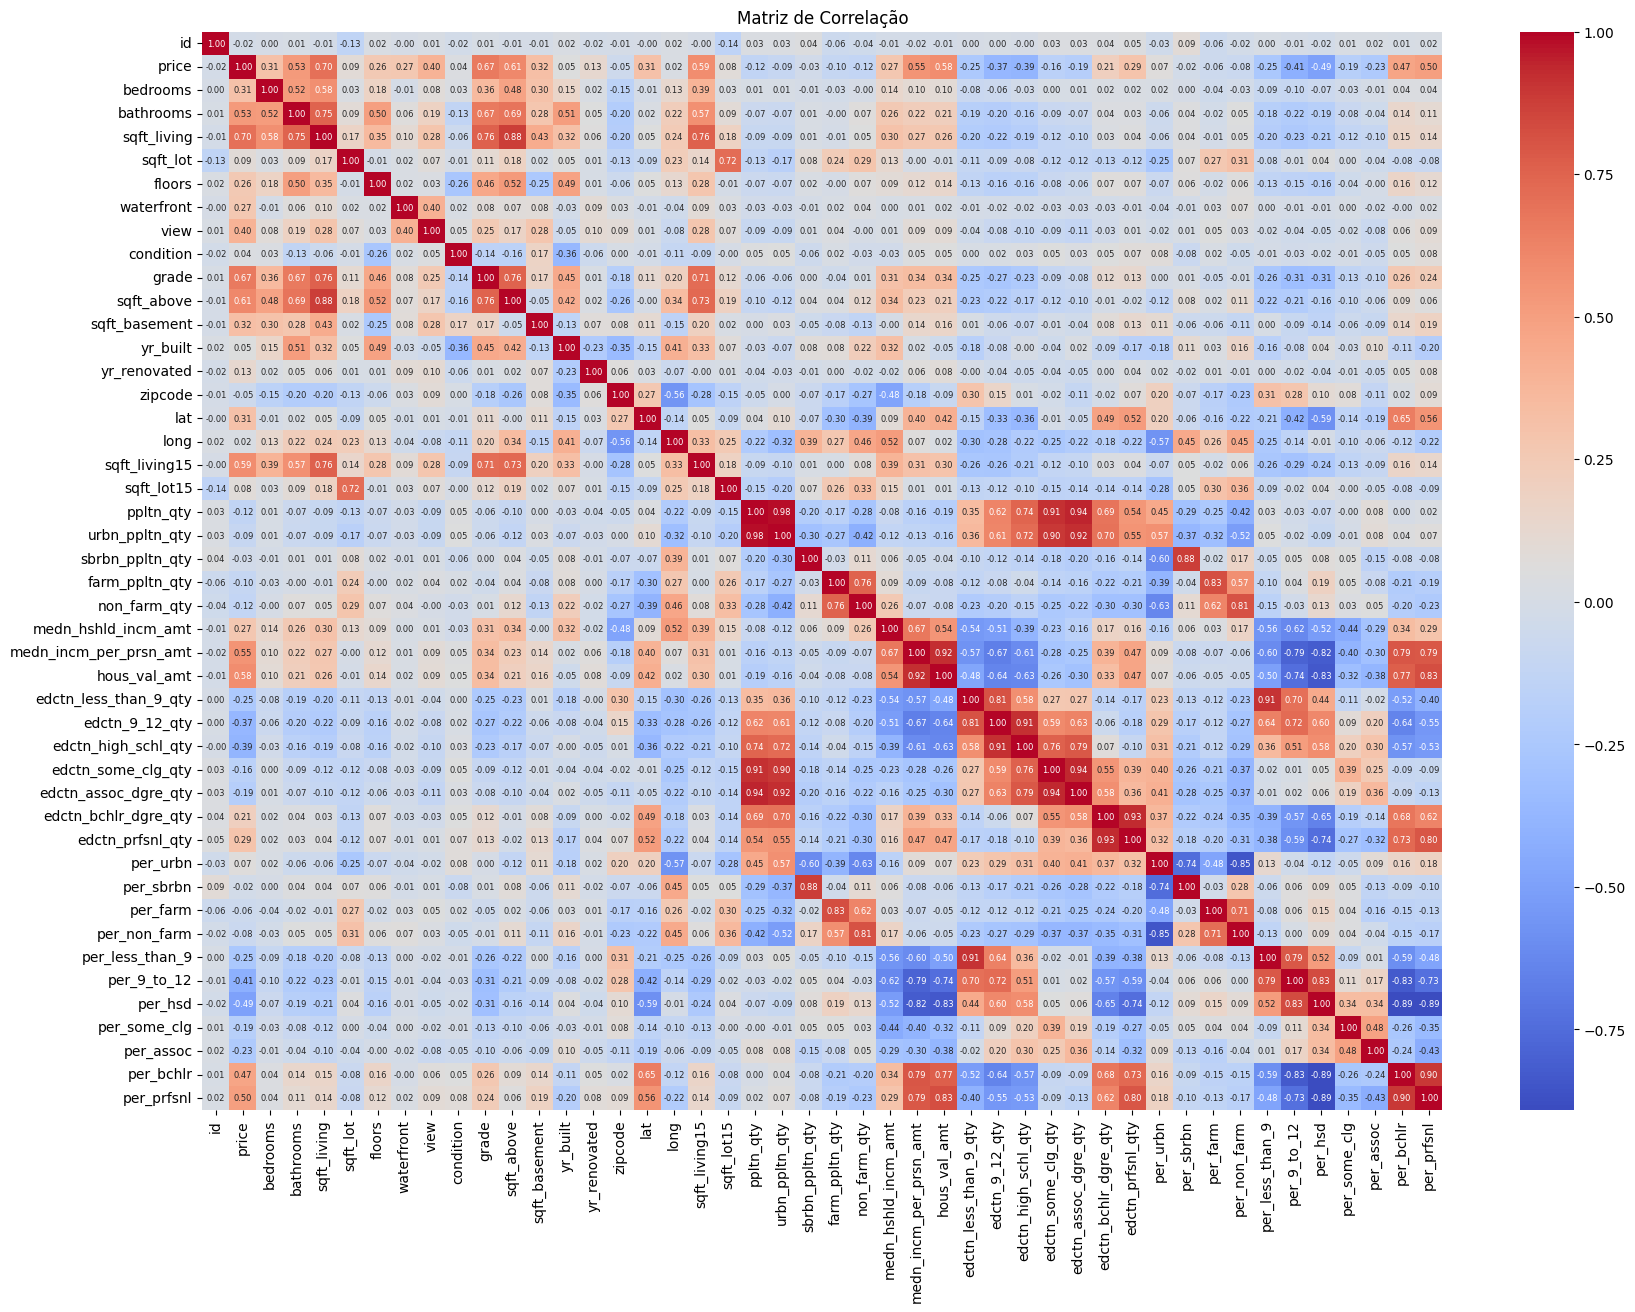

In [87]:
plt.figure(figsize=(20,14))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 6}
)
plt.title('Matriz de Correlação')
plt.show()

##Matriz de correlação filtrada

Renomeei os indices para ficar melhor a vizualização no relatório.

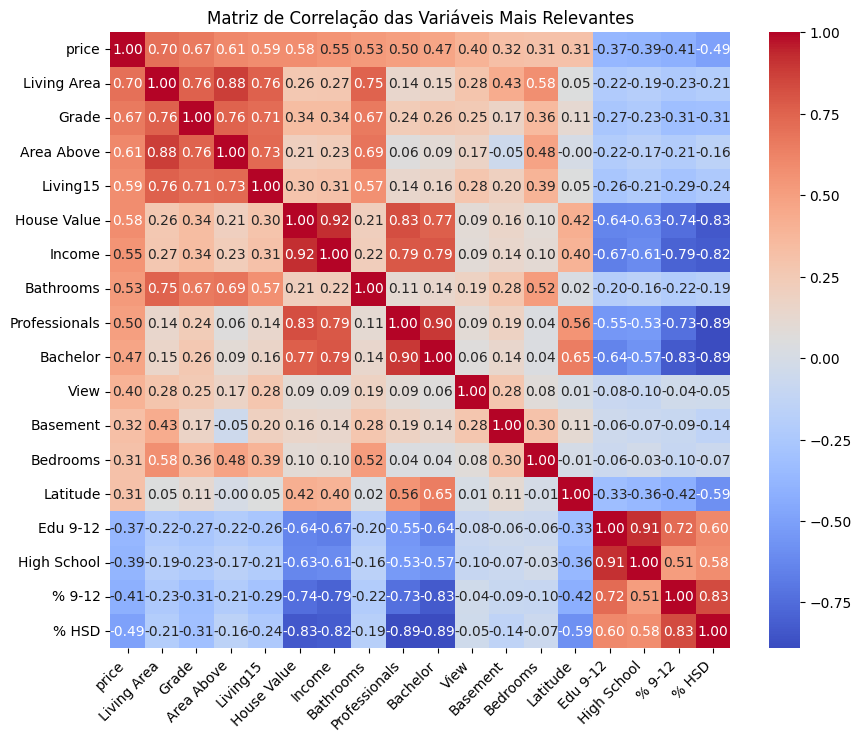

In [88]:
selected_features = price_corr_filtered.index.tolist()
selected_features = ['price'] + selected_features
corr_selected = full_data[selected_features].corr(numeric_only=True)

corr_plot = corr_selected.rename(columns={
    'sqft_living': 'Living Area',
    'grade': 'Grade',
    'sqft_above': 'Area Above',
    'sqft_living15': 'Living15',
    'hous_val_amt': 'House Value',
    'medn_incm_per_prsn_amt': 'Income',
    'bathrooms': 'Bathrooms',
    'per_prfsnl': 'Professionals',
    'per_bchlr': 'Bachelor',
    'view': 'View',
    'sqft_basement': 'Basement',
    'bedrooms': 'Bedrooms',
    'lat': 'Latitude',
    'edctn_9_12_qty': 'Edu 9-12',
    'edctn_high_schl_qty': 'High School',
    'per_9_to_12': '% 9-12',
    'per_hsd': '% HSD'
})

corr_plot.index = corr_plot.columns

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_plot,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 10}
)
# Ajusta labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Matriz de Correlação das Variáveis Mais Relevantes')
plt.show()

##Outliers e distribuição

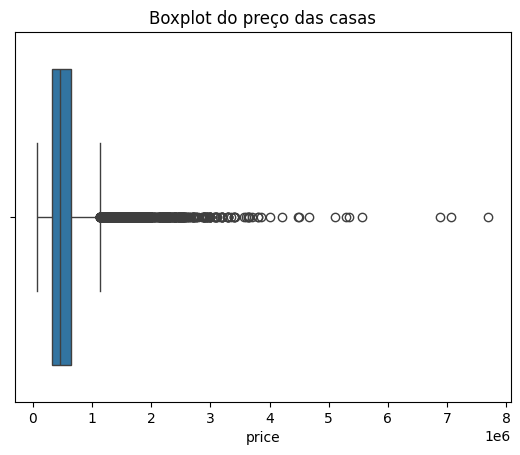

In [89]:
sns.boxplot(x=full_data['price'])

plt.title('Boxplot do preço das casas')
plt.show()

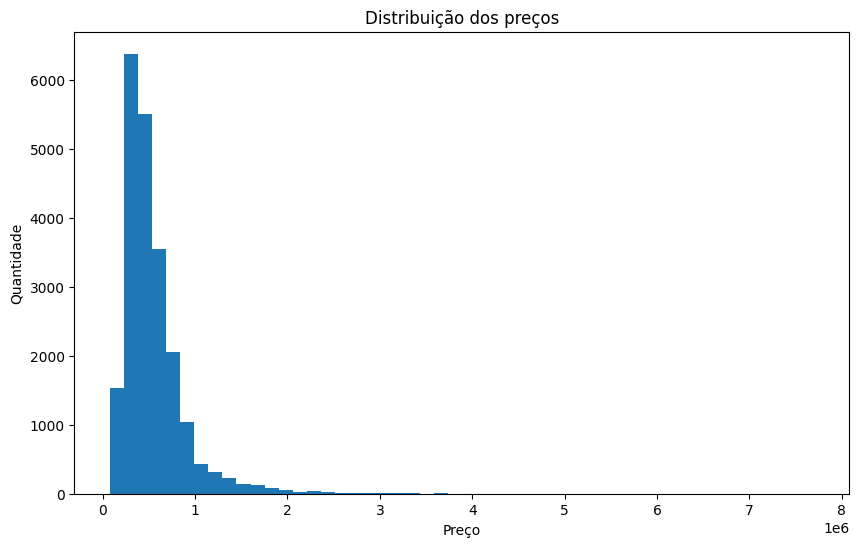

In [90]:
plt.figure(figsize=(10,6))

plt.hist(full_data['price'], bins=50)

plt.title('Distribuição dos preços')
plt.xlabel('Preço')
plt.ylabel('Quantidade')

plt.show()

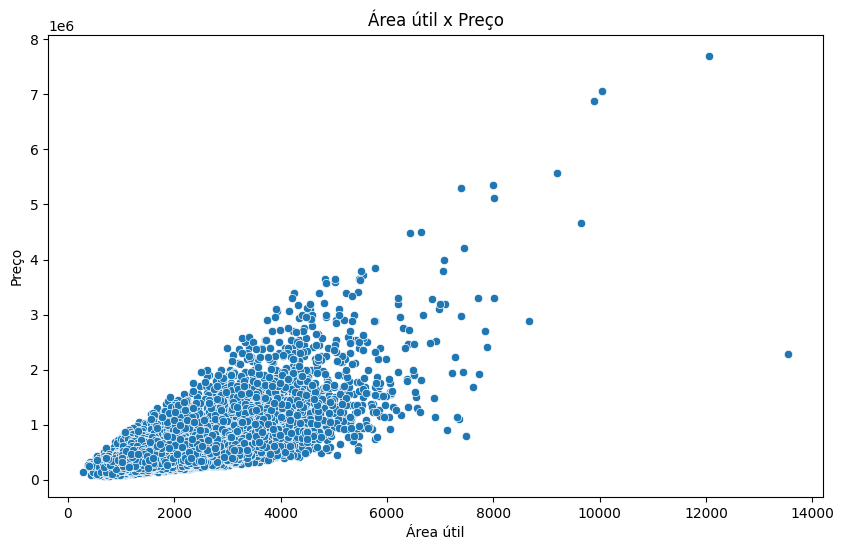

In [91]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=full_data['sqft_living'],
    y=full_data['price']
)

plt.title('Área útil x Preço')
plt.xlabel('Área útil')
plt.ylabel('Preço')

plt.show()

#Pre-processamento


In [92]:
full_data = full_data.dropna(subset=['price'])
full_data = full_data.drop(columns=['id', 'date'])

In [93]:
X = full_data.drop('price', axis=1)
y = full_data['price']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#MLP Regressor

In [95]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

In [108]:
mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42)

In [109]:
y_pred = mlp.predict(X_test)

#Avaliar Desempenho

In [110]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 73731.19916760101
MSE: 17305743151.82687
R²: 0.8855263956103002
